Scattering/2025-11-16_12_56_31


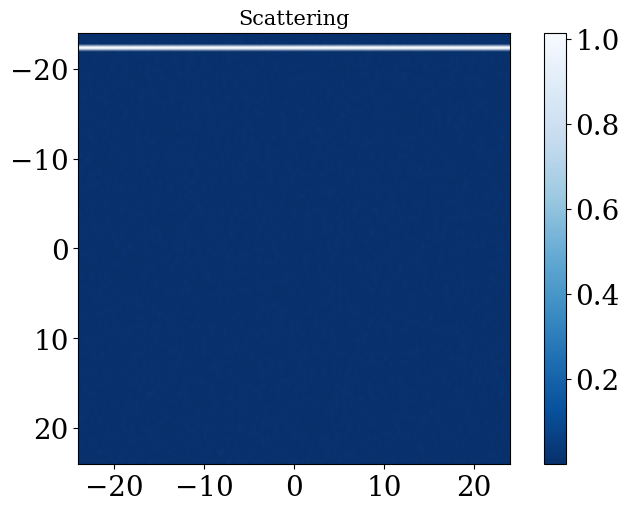

In [1]:
import numpy as np
from PIL import Image
import scipy as sci
import matplotlib.pyplot as plt
from matplotlib import colors
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output  # clear_output(wait=True)
import time
import os
import sys
import h5py

# os.chdir('D:/Documents/PostDoc_KTH/WACQT_Project/ScrptCodes') # on Laptop
# os.chdir('../../')  # on Desktop
# sys.path.append(os.getcwd())
import myPy_functions as my

#Frequency comb and JPA parameters
f0=4.2           #[GHz] Resonance frequency of the JPA
omega0=2*np.pi*f0
Delta_f=0.1e-3   #[GHz] Modes spacing (typically 100KHz)
Delta=2*np.pi*Delta_f 
c = 299_792_458  # [m/s]


#Style
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = False
plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

# Load Exp Data
def load_ExpData(file_, idx_str_):
    # Open hdf5 file
    with h5py.File(file_, "r") as dataset:
        # Data
        return dict(freq_comb=np.asarray(dataset[idx_str_]["freq comb"]),
                    freq_pump=np.asarray(dataset[idx_str_]["freq pumps"]),
                    pump_pwr_data=np.asarray(dataset[idx_str_]["pump pwr sweep"]),
                    pump_phase_data=np.asarray(dataset[idx_str_]["pump phase sweep"]),
                    df=np.asarray(dataset[idx_str_]["df"]),
                    USB=np.asarray(dataset[idx_str_]["USB"]),
                    )
    
#New Data three pumps
cooldown = r'Scattering'

file = r'Data_Img.hdf5'
run = '2025-11-16_12_56_31' # Test Npumps, img PeaceFilmx2_96x151.png, df=[100K], Npix5k and pump amplitude sweep [0..0.035] with norm 20, amp_sig=0.01 - input fs_comb[3] NEW MODES def.
case_Sl='PeaceFilmx2_96x151'
input_mode=3


idx_str = "{}/{}".format(cooldown, run)
print(idx_str)
USB = load_ExpData(file, idx_str)["USB"]
df = load_ExpData(file, idx_str)["df"]
Sexp_tot = USB[:, :, 0, :, :]
shapevec = Sexp_tot.shape
# print(shapevec)
Ndf = shapevec[0]
Ng = shapevec[1]
Nphases = shapevec[2]
Nmodes = shapevec[3]

# Generate frequency vectors
modes_freq,modes_labels,allmodes_freq = my.generate_freq_vectors(Nmodes,omega0,Delta)
modes_freq_GHz = modes_freq / (2 * np.pi )  # Convert to GHz


# Compute reference
S0exp_ref=np.zeros(Ndf)
backgnd_dB=np.zeros(Ndf)
for df_idx in range(Ndf):
    Sref_T = np.squeeze(Sexp_tot[df_idx, 0, :, :])  # Select case 0 power as a reference case
    Sref=np.transpose(Sref_T)
    # S0exp_ref[df_idx] = np.mean(np.abs(np.diag(Sref)))  # Compute the mean of the diagonal element
    S0exp_ref[df_idx] = np.mean(np.abs(Sref[input_mode,:]))  # Compute the mean of the first row elements (where signal is injected)
    background = np.mean(np.abs(Sref[2:20, 30:60]))
    backgnd_dB[df_idx] = my.dB(background / S0exp_ref[df_idx])

fig1, ax1 = plt.subplots(1, 1, figsize=(8,5))
my.plot_Matrix(np.abs(Sref[0::1,:])/S0exp_ref[df_idx], str='Scattering', col_map='Blues_r', fig=fig1, ax=ax1)

global Sexp_tot
global S0exp_ref
global backgnd_dB
global Ndf
global Ng
global Nphases
global Nmodes
global df

In [2]:
def stuff_to_run_and_display(df_value,g_value,phNoise_value):
    df_idx = df_value
    g_idx = g_value
    phNoise_dB = phNoise_value
    
    global Sexp_tot
    global S0exp_ref
    global backgnd_dB
    global Ndf
    global Ng
    global Nphases
    global Nmodes
    global df

    Sexp_T = np.squeeze(Sexp_tot[df_idx, g_idx, :, :]) 
    Sexp=np.transpose(Sexp_T)
    Sexp_abs = np.abs(Sexp)/S0exp_ref[df_idx]
    Sexp_abs_dB = my.dB(Sexp_abs/S0exp_ref[df_idx])
    Nx=Sexp_abs.shape[0]
    Ny=Sexp_abs.shape[1]

    ### Plotting
    print('Ref', S0exp_ref[df_idx])
    top=Nmodes//2
    start_mode=0

    global fig1
    # Test
    fig1, ax1 = plt.subplots(1, 1, figsize=(18,5))
    pl01=ax1.imshow(Sexp_abs[start_mode::1,:], cmap='GnBu_r', extent=[0, Ny, top, -top], aspect='auto')
    plt.colorbar(pl01, ax=ax1, label='Amplitude F.S.')
    ax1.set_title('Scattering')

    # Test
    global fig2
    fig2, ax2 = plt.subplots(1, 1, figsize=(18,5))
    pl02=ax2.imshow(my.dB(Sexp_abs[start_mode::1,:]), cmap='GnBu_r', extent=[0, Ny, top, -top],vmin = -40, vmax = 0, aspect='auto')
    plt.colorbar(pl02, ax=ax2, label='Amplitude [dB]')
    ax2.set_title('Scattering')



    return


    
# Main Code:
df_slider=widgets.IntSlider(min=0,max=Ndf-1,step=1,value=0,description='df')
g_slider=widgets.IntSlider(min=0,max=Ng-1,step=1,value=9,description='g')
phNoise_slider = widgets.FloatSlider(min=-60.0, max=10.0, step=0.1, value=-35, description='$\phi$ noise [dB]')


widgets.interact(stuff_to_run_and_display, df_value = df_slider, g_value = g_slider, phNoise_value = phNoise_slider)
                                          

plt.show()   

interactive(children=(IntSlider(value=0, description='df', max=0), IntSlider(value=9, description='g', max=10)…

### Figure 5 - Image

Text(0.5, 0, '$t/T$')

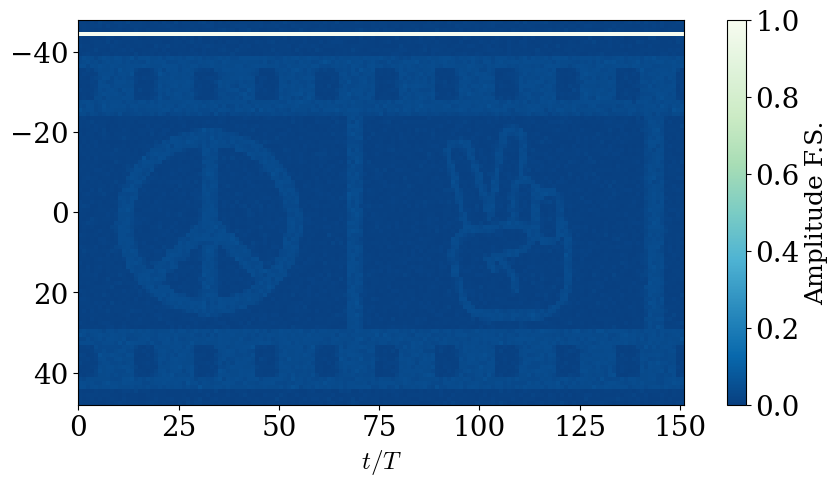

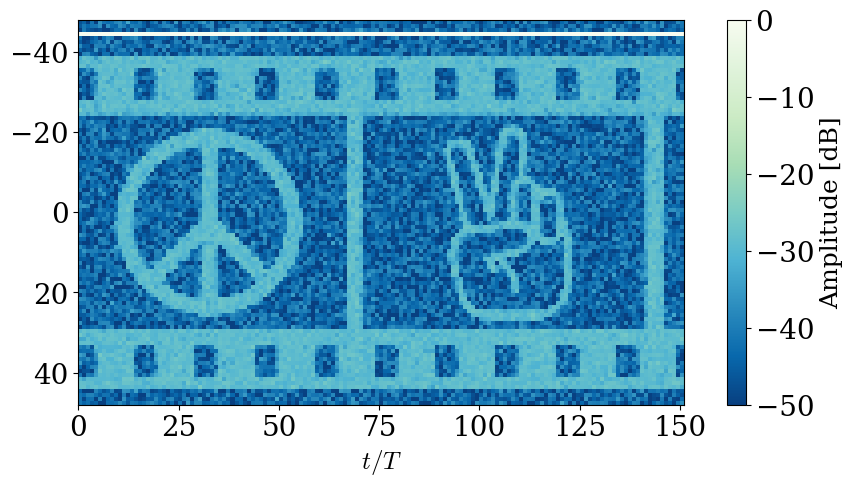

In [3]:
#Style
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = False #True
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = False
plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

# Case Selection
df_idx = 0
g_idx = 9
phNoise_dB=-60

Sexp_T = np.squeeze(Sexp_tot[df_idx, g_idx, :, :]) #- np.squeeze(Sexp_tot[df_idx, 0, :, :])
Sexp=np.transpose(Sexp_T)
Sexp_abs = np.abs(Sexp)/S0exp_ref[df_idx]
Nx=Sexp_abs.shape[0]
Ny=Sexp_abs.shape[1]

### Plotting
start_mode=0
top=Nmodes//2
asp_ratio=Ny/Nx  #Horizontal over Vertical

# Linear
fig3, ax3 = plt.subplots(1, 1, figsize=(7*asp_ratio,5))
pl02=ax3.imshow(Sexp_abs[start_mode::1,:], cmap='GnBu_r', extent=[0, Ny, top, -top],vmin = 0, vmax = 1, aspect ='equal')
# ax3.axis('equal')
plt.colorbar(pl02, ax=ax3, label='Amplitude F.S.')
# ax3.set_title('Linear')
ax3.set_xlabel('$t/T$')
# dB
fig4, ax4 = plt.subplots(1, 1, figsize=(7*asp_ratio,5))
pl02=ax4.imshow(my.dB(Sexp_abs[start_mode::1,:]), cmap='GnBu_r', extent=[0, Ny, top, -top],vmin = -50, vmax = 0, aspect ='equal')
# pl02=ax4.imshow(my.dB(Sexp_abs[start_mode::1,:]), cmap='gist_heat', extent=[0, Nmodes, top, -top],vmin = -40, vmax = -10)
plt.colorbar(pl02, ax=ax4, label='Amplitude [dB]')
# ax4.set_title('dB')
ax4.set_xlabel('$t/T$')

In [4]:
#Save Figures
import os

save=False  #False #True
if save==True:
    folder="Figures_InvProblem/"
    if not os.path.isdir(folder):
        os.makedirs(folder)
        print(folder)
    str= time.strftime("%Y-%m-%d_%H_%M_%S")
    filename = "ScattImage_dB_{}".format(str)
    filepath = os.path.join(folder, filename)
    fig4.savefig(os.path.join(folder, filename + '.png'), bbox_inches='tight', dpi=300)
    fig4.savefig(os.path.join(folder, filename + '.svg'), bbox_inches='tight')
    fig4.savefig(os.path.join(folder, filename + '.pdf'), bbox_inches='tight')
    print("Figures saved in folder: ",  filepath)

Text(0.5, 1.0, 'dB')

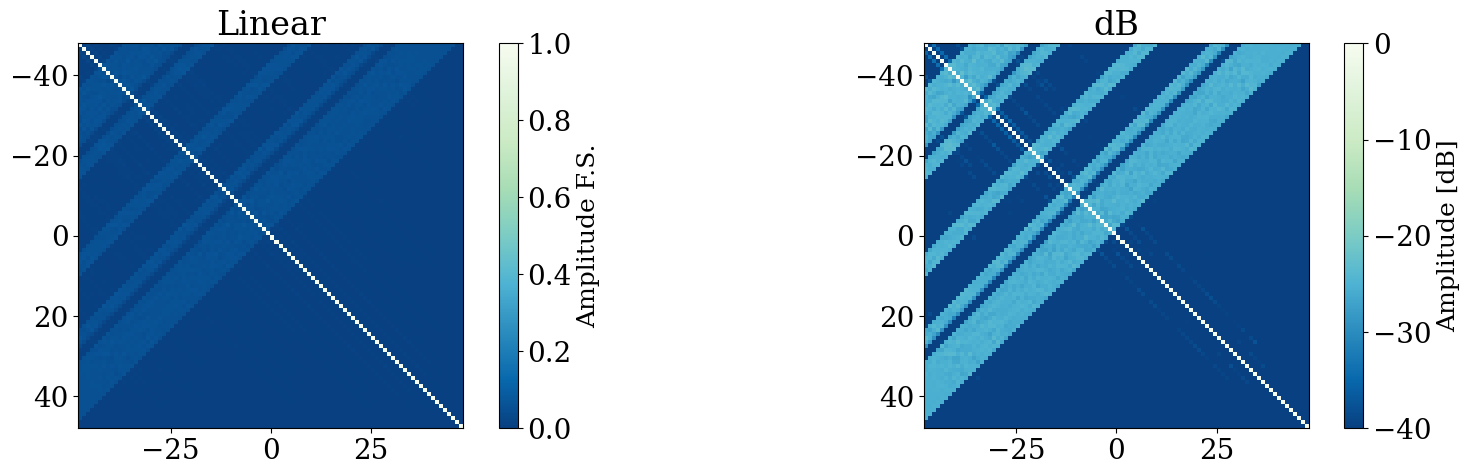

In [5]:
# Load
fname='Stargets_Image_{}.npz'.format(case_Sl)
data = np.load(fname)
omega_k=data['omega_k']
phi_k=data['phi_k'] 
Ap_k=data['Ap_k']
Sa_saved=data['Sa_saved'] 
Sref_saved=data['Sref_saved']

# Case Selection
i=35
Sa_small=Sa_saved[i,:,:]
Sref=Sref_saved[i]
Sa_abs=np.abs(Sa_small)
Saved_eg=Sa_abs
Saved_ref=Sref
saved_ell=i

#Plot
fig0, ax0 = plt.subplots(1, 2, figsize=(20,5))
# Linear
pl02=ax0[0].imshow(Saved_eg/Saved_ref, cmap='GnBu_r', extent=[-top, top, top, -top],vmin = 0, vmax = 1)
plt.colorbar(pl02, ax=ax0[0], label='Amplitude F.S.')
ax0[0].set_title('Linear')
# dB
pl02=ax0[1].imshow(my.dB(Saved_eg/Saved_ref + 1e-15), cmap='GnBu_r', extent=[-top, top, top, -top],vmin = -40, vmax = 0)
plt.colorbar(pl02, ax=ax0[1], label='Amplitude [dB]')
ax0[1].set_title('dB')


Text(0.5, 1.0, '$|S_\\ell|$')

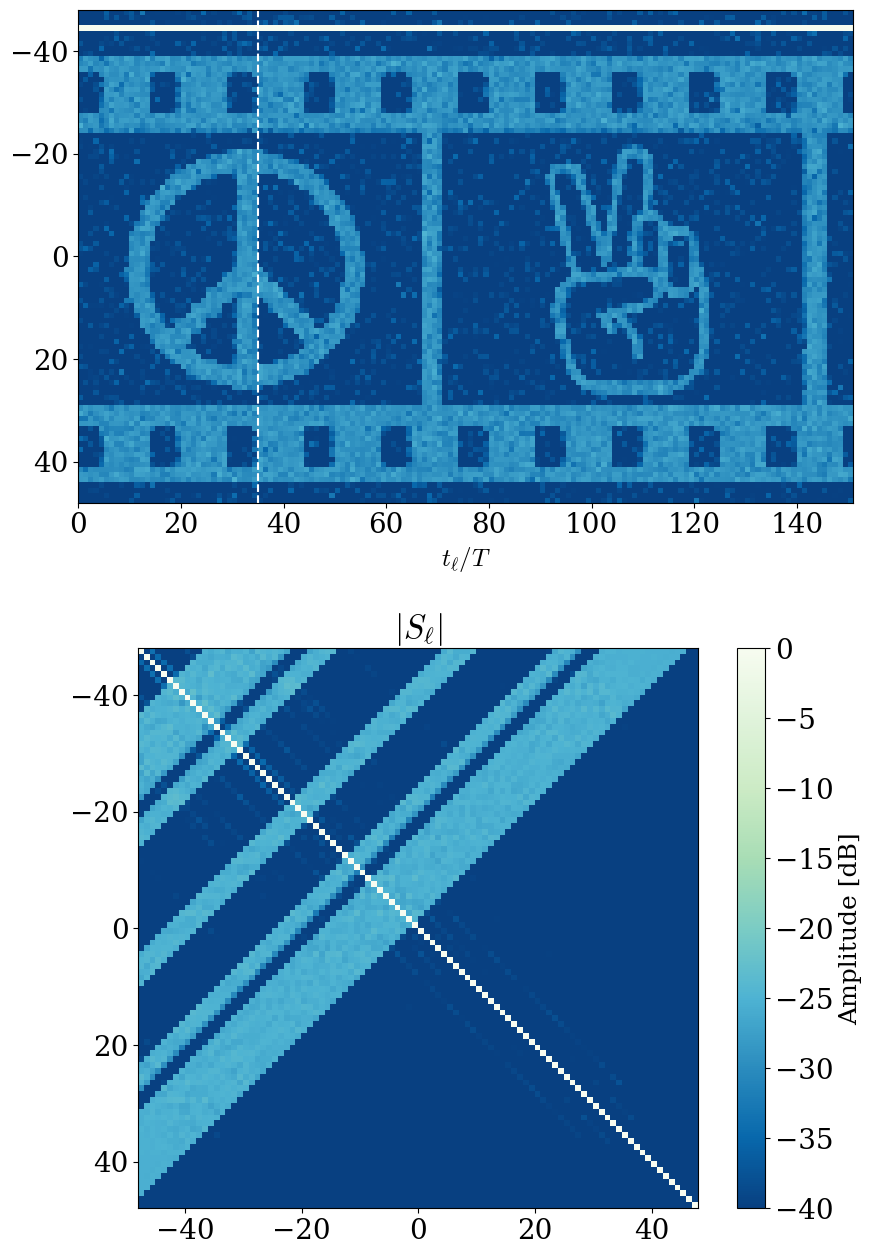

In [6]:
# dB
fig5, ax5 = plt.subplots(2, 1, figsize=(10,16))
pl02=ax5[0].imshow(my.dB(Sexp_abs[start_mode::1,:]), cmap='GnBu_r', extent=[0, Ny, top, -top],vmin = -40, vmax = 0, aspect ='equal')
# plt.colorbar(pl02, ax=ax5[0], label='Amplitude [dB]')
ax5[0].axvline(saved_ell, color='w', linestyle='--')
ax5[0].set_xlabel('$t_\ell/T$')

pl02=ax5[1].imshow(my.dB(Saved_eg/Saved_ref + 1e-15), cmap='GnBu_r', extent=[-top, top, top, -top],vmin = -40, vmax = 0, aspect ='equal')
plt.colorbar(pl02, ax=ax5[1], label='Amplitude [dB]')
ax5[1].set_title('$|S_\ell|$')

In [7]:
#Save Figures
import os

save=False  #False #True
if save==True:
    folder="Figures_InvProblem/"
    if not os.path.isdir(folder):
        os.makedirs(folder)
        print(folder)
    str= time.strftime("%Y-%m-%d_%H_%M_%S")
    filename = "ScattImage_Starget_dB_{}".format(str)
    filepath = os.path.join(folder, filename)
    fig5.savefig(os.path.join(folder, filename + '.png'), bbox_inches='tight', dpi=300)
    fig5.savefig(os.path.join(folder, filename + '.svg'), bbox_inches='tight')
    fig5.savefig(os.path.join(folder, filename + '.pdf'), bbox_inches='tight')
    print("Figures saved in folder: ",  filepath)

0.125 0.3564238410596026 0.9 0.6335761589403974


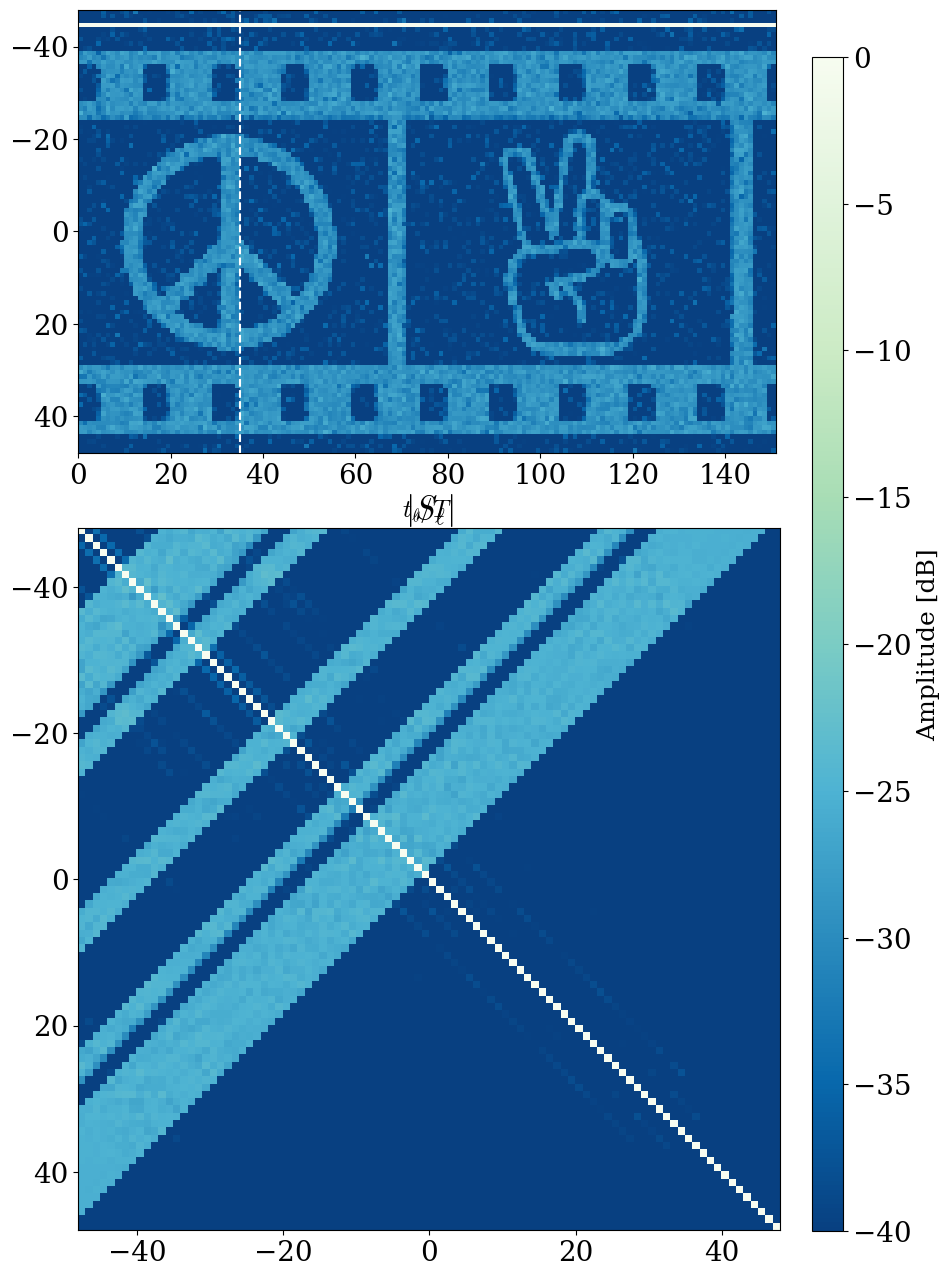

In [8]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax1 = plt.subplots(1, 1, figsize=(9,16))

# Create two plots
im1 = ax1.imshow(my.dB(Sexp_abs[start_mode::1,:]), cmap='GnBu_r', extent=[0, Ny, top, -top],vmin = -40, vmax = 0, aspect ='equal')#imshow(np.random.rand(10, 10))
ax1.axvline(saved_ell, color='w', linestyle='--')
ax1.set_xlabel('$t_\ell/T$')

pos_ax=np.array(ax1.get_position(original=False))
left=pos_ax[0][0]
bottom=pos_ax[0][1]
width= pos_ax[1][0]
heigth= pos_ax[1][1]
print(left, bottom, width, heigth)

ax2 = fig.add_axes([left, -0.36, 0.78, width])
im2 = ax2.imshow(my.dB(Saved_eg/Saved_ref + 1e-15), cmap='GnBu_r', extent=[-top, top, top, -top],vmin = -40, vmax = 0, aspect ='equal')
ax2.set_title('$|S_\ell|$')

# Manually create an axes for the colorbar
cbar_ax = fig.add_axes([0.94,-0.13, 0.035, 0.734])

# Create colorbar using the new axes
cbar = fig.colorbar(im1, cax=cbar_ax, label='Amplitude [dB]')
plt.show()

In [9]:
#Save Figures
import os

save=False  #False #True
if save==True:
    folder="Figures_InvProblem/"
    if not os.path.isdir(folder):
        os.makedirs(folder)
        print(folder)
    str= time.strftime("%Y-%m-%d_%H_%M_%S")
    filename = "ScattImage_Starget_dB_{}".format(case_Sl)
    filepath = os.path.join(folder, filename)
    fig.savefig(os.path.join(folder, filename + '.png'), bbox_inches='tight', dpi=300)
    fig.savefig(os.path.join(folder, filename + '.svg'), bbox_inches='tight')
    fig.savefig(os.path.join(folder, filename + '.pdf'), bbox_inches='tight')
    print("Figures saved in folder: ",  filepath)